# Stock Market Technical Analysis & Indicators

This notebook simulates stock price behaviors and calculates popular technical indicators: Simple Moving Average (SMA), Exponential Moving Average (EMA), and the Relative Strength Index (RSI). These indicators are widely used in algorithmic trading and as features for predictive machine learning models.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate simulated stock price data using a random walk with drift
np.random.seed(42)
days = 252
dates = pd.date_range(start="2025-01-01", periods=days, freq="D")
initial_price = 150.0
drift = 0.15 / days  # Annual return drift
volatility = 0.25 / np.sqrt(days)  # Annualized volatility

daily_returns = np.random.normal(drift, volatility, days)
price_path = initial_price * np.exp(np.cumsum(daily_returns))

df = pd.DataFrame({
    "Date": dates,
    "Close": price_path
})
df.set_index("Date", inplace=True)
df.head(10)



,Close
Date,
2025-01-01,151.267992
2025-01-02,151.028842
2025-01-03,152.668087
2025-01-04,156.467278
2025-01-05,155.984177
2025-01-06,155.502607
2025-01-07,159.513411
2025-01-08,161.549113
2025-01-09,160.454580


## Technical Indicators Calculations

We define helper functions to calculate SMAs, EMAs, and the Relative Strength Index (RSI).
RSI measures the speed and change of price movements, fluctuating between 0 and 100. Traditionally, values over 70 indicate overbought conditions, and values under 30 indicate oversold conditions.



In [2]:
# 1. Simple Moving Average (SMA)
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# 2. Exponential Moving Average (EMA)
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

# 3. Relative Strength Index (RSI)
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    # Calculate RS
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI_14'] = calculate_rsi(df['Close'], period=14)
df.tail(10)



,Close,SMA_20,EMA_50,RSI_14
Date,,,,
2025-08-31,170.692346,170.564985,165.547097,53.927392
2025-09-01,173.138594,170.672984,165.844803,54.793143
2025-09-02,169.997671,170.682186,166.007660,52.399812
2025-09-03,169.205183,170.499756,166.133053,49.917583
2025-09-04,168.044299,170.245376,166.208004,47.662711
2025-09-05,166.423193,170.050562,166.216443,47.677099
2025-09-06,171.217115,170.185823,166.412548,45.776911
2025-09-07,172.415201,170.285258,166.647946,44.558938
2025-09-08,169.125951,170.312666,166.745123,48.086128


## Technical Analysis Visualization

We construct a multi-panel plot. The top panel shows the simulated closing price alongside its 20-day SMA and 50-day EMA. The bottom panel displays the 14-day RSI, complete with standard overbought (70) and oversold (30) boundary marks.



<cell>:24: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



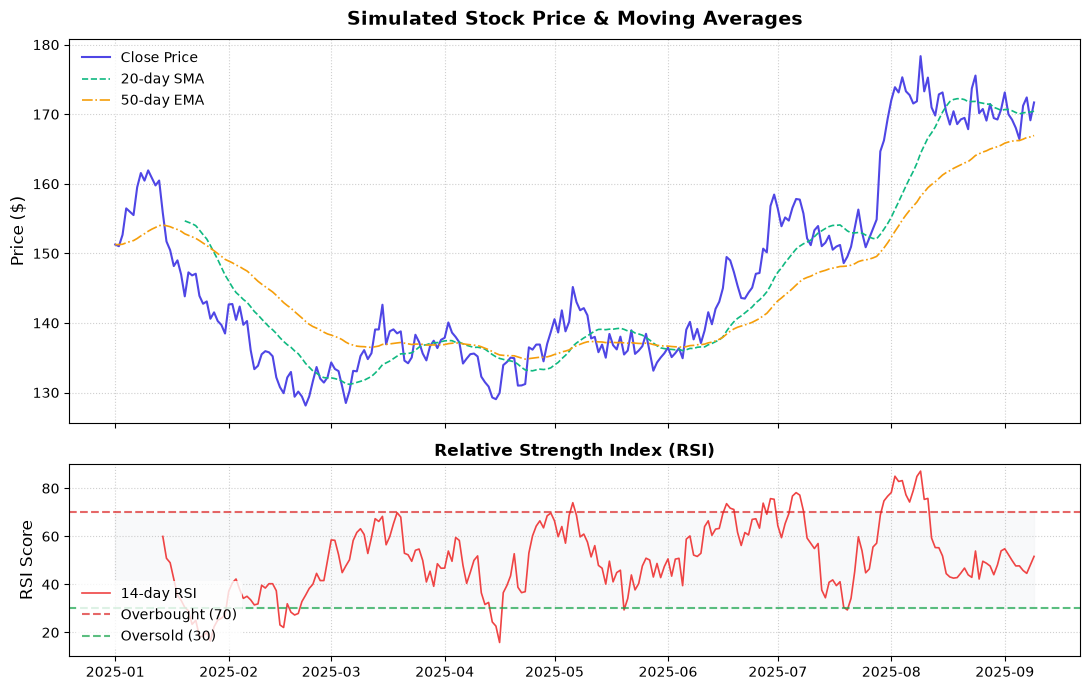

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top subplot: Prices & MAs
ax1.plot(df.index, df['Close'], label='Close Price', color='#4F46E5', linewidth=1.5)
ax1.plot(df.index, df['SMA_20'], label='20-day SMA', color='#10B981', linestyle='--', linewidth=1.2)
ax1.plot(df.index, df['EMA_50'], label='50-day EMA', color='#F59E0B', linestyle='-.', linewidth=1.2)
ax1.set_title('Simulated Stock Price & Moving Averages', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax1.grid(True, linestyle=':', alpha=0.6)

# Bottom subplot: RSI
ax2.plot(df.index, df['RSI_14'], label='14-day RSI', color='#EF4444', linewidth=1.2)
ax2.axhline(70, color='#DC2626', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(30, color='#16A34A', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.fill_between(df.index, 30, 70, color='#F3F4F6', alpha=0.5)
ax2.set_title('Relative Strength Index (RSI)', fontsize=12, fontweight='bold')
ax2.set_ylabel('RSI Score', fontsize=12)
ax2.set_ylim(10, 90)
ax2.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
